Time Series data refer to data that is collect, recorded or observed over time in a sequential order.

Characteristics:
1. Chronological Order: Observation are ordered in time(D,W,M,Y,s,m,h)(day,week,month,year,sec,min,hour)
2. Sequential Order: The order of data matters because previous  value can influence or predict the future values.
3. Temporal Components: Trend,Seasonality, Cycle,noise

Time series Analysis:
* statistical technique: meaning insights about pattern and trends.
* forecasting

Time Series Decomposition

* Trend: long term direction
* Seasonality: repeting pattern at fixed interval.
* Noise  ( will not be capture)

```Classical Decomposition```

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [23]:
df=pd.read_csv("AirPassengers.csv",parse_dates=["Month"],index_col="Month")
df=df.rename(columns={'#Passengers':'Passengers'})
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Text(0, 0.5, 'Passenger')

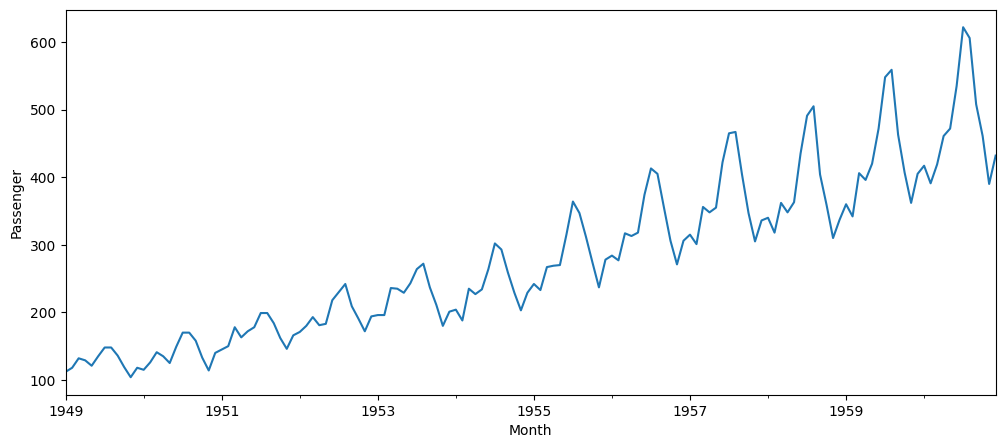

In [24]:
df["Passengers"].plot(figsize=(12,5))
plt.xlabel("Month")
plt.ylabel("Passenger")

The graph show the seasonality because we see same pattern in every year only they are magnifiying each year the follow same patter. It show seasonalty. Some amount of noise also available but we are not able to capture by trend or season.

So what we do to capture Noise. Let say we have trend component or season component. So what we should do,add all decomposition or multiply all decomposition to get the final time series. 
There are two way to do it:
* Additive Model
* Multiplicative Model

When apply "Additive Model" when you see graph is very constant i.e the peek and bottom are same size. Its ia upward trend okay and not changing across time.When we see balanced trend across over time. When we have this type of chart we use Additive Model. here trend is linear.

When apply "Multiplicative Model" when you see small grow in early days and later on it is increase so when graph grow exponentially . In  this case we should do multiplication of trend and season. here trend is exponential.
 

Additive yi=T+S+R   (if we want to predict yi and if I want what is my time series data is its going to be (Trend)+(season)+(Residual or Noise))

Multiplicative yi=T*S*R  (if we want to predict yi and if I want what is my time series data is its going to be (Trend)*(season)*(Residual or Noise))


From graph we decide which type of model we have to build.

In [26]:
import yfinance as yf
ticker_symbol='Reliance.NS'
stock_data=yf.download(ticker_symbol,start='2023-01-01',end='2025-08-01',interval="1d")
stock_data.columns=stock_data.columns.droplevel("Ticker")
stock_data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597
...,...,...,...,...,...
2025-07-25,1386.163696,1395.426749,1378.593954,1393.335127,11854722
2025-07-28,1382.080078,1402.199795,1379.490445,1386.761454,7748361
2025-07-29,1411.462769,1414.550412,1377.498442,1377.498442,10750072
